In [20]:
%matplotlib widget

In [21]:
from zarr_store import ZarrStore
import matplotlib.pyplot as plt

In [22]:
store = ZarrStore.create('../../../out')
display(store.create_ui())

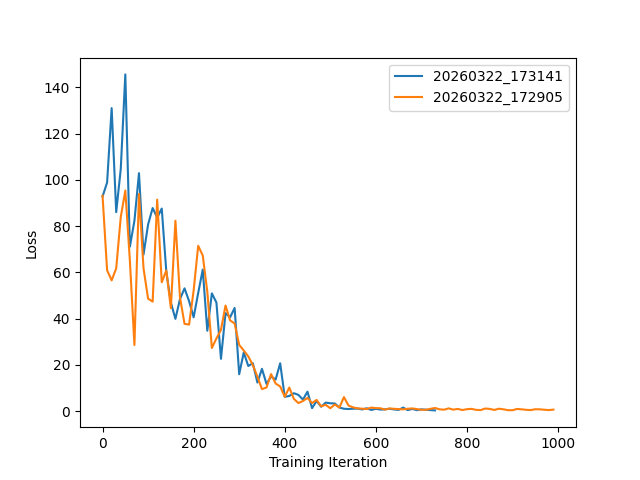

In [23]:
# Usage
losses = store.load_metric('train/loss')
for run_name, (steps, loss) in losses.items():
    plt.plot(steps, loss, label=run_name)
plt.xlabel("Training Iteration")
plt.ylabel("Loss")
plt.legend()
plt.show()

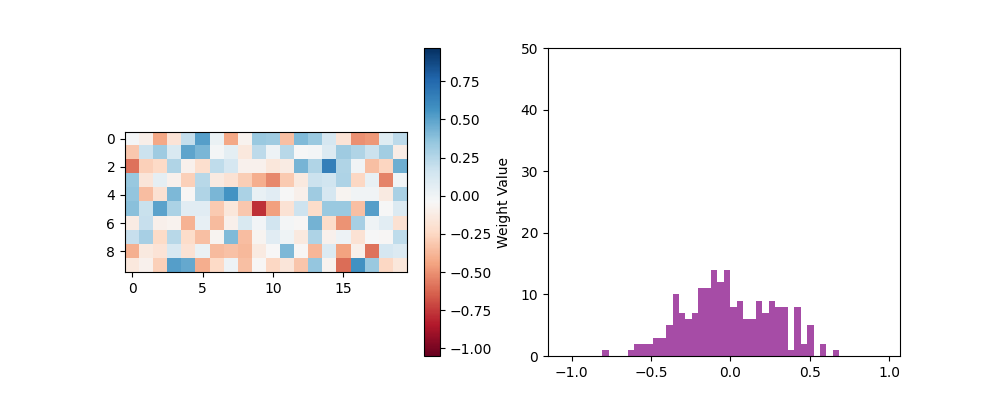

In [28]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np

def visualize_weights_pro(run_name: str, layer_name: str):
    # --- Data (Mocked for example) ---
    steps, weights = store.load_metric_for(run_name, layer_name)
    max_iteration = len(weights)
    all_w = np.concatenate([w.flatten() for w in weights])
    min_w, max_w = np.min(all_w), np.max(all_w)

    # 1. UI Elements
    play = widgets.Play(interval=100, min=0, max=max_iteration-1, step=1)
    slider = widgets.IntSlider(min=0, max=max_iteration-1, description='Step', continuous_update=False)
    speed_input = widgets.BoundedIntText(value=100, min=100, max=2000, step=50, description='Speed (ms)')
    step_input = widgets.BoundedIntText(value=1, min=1, max=100, step=1, description='Jump:')

    widgets.jslink((play, 'value'), (slider, 'value'))
    widgets.jslink((speed_input, 'value'), (play, 'interval'))
    widgets.jslink((step_input, 'value'), (play, 'step'))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    
    init_w = weights[0]
    if init_w.ndim >= 2:
        im = ax1.imshow(init_w if init_w.ndim == 2 else init_w[0], cmap='RdBu', vmin=min_w, vmax=max_w)
        fig.colorbar(im, ax=ax1, label='Weight Value')
    else:
        im, = ax1.plot(init_w)
        ax1.set_ylim(min_w, max_w)

    hist_bins = np.linspace(min_w, max_w, 51)
    counts, _ = np.histogram(init_w.flatten(), bins=hist_bins)
    bar_container = ax2.bar(hist_bins[:-1], counts, width=np.diff(hist_bins), align='edge', color='purple', alpha=0.7)
    ax2.set_ylim(0, init_w.size // 4) 

    def update_plot(change):
        index = change['new'] if isinstance(change, dict) else change
        if index >= len(weights): return
        
        w = weights[index]
        
        if init_w.ndim >= 2:
            im.set_data(w if w.ndim == 2 else w[0])
        else:
            im.set_ydata(w)
            
        counts, _ = np.histogram(w.flatten(), bins=hist_bins)
        for rect, h in zip(bar_container, counts):
            rect.set_height(h)
        
        ax1.set_title(f"Step: {steps[index]}")
        ax2.set_title(f"Mean: {w.mean():.4f}")
        
        fig.canvas.draw_idle()

    slider.observe(update_plot, names='value')

    # 4. LAYOUT
    # We place fig.canvas directly into the VBox. It is treated like any other widget.
    controls = widgets.HBox([play, slider, speed_input, step_input])
    ui = widgets.VBox([controls, fig.canvas])
    
    display(ui)

# Usage:
run_name = store.run_names[-1]
visualize_weights_pro(run_name, 'train/params/hiddenLayer.weight')